In [2]:
from datasets import load_dataset, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re, warnings
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig,TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
warnings.filterwarnings('ignore')

/home/leeze/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_NAME = "iamtarun/python_code_instructions_18k_alpaca"

dataset = load_dataset(DATASET_NAME)
print(dataset)
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output', 'prompt'],
        num_rows: 18612
    })
})
{'instruction': 'Create a function to calculate the sum of a sequence of integers.', 'input': '[1, 2, 3, 4, 5]', 'output': '# Python code\ndef sum_sequence(sequence):\n  sum = 0\n  for num in sequence:\n    sum += num\n  return sum', 'prompt': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nCreate a function to calculate the sum of a sequence of integers.\n\n### Input:\n[1, 2, 3, 4, 5]\n\n### Output:\n# Python code\ndef sum_sequence(sequence):\n  sum = 0\n  for num in sequence:\n    sum += num\n  return sum'}


In [3]:
#Loading data
df = dataset['train'].to_pandas()

#Check missing value
print("Missing values:")
print(df.isnull().sum())

print("\nEmpty string count:")
print((df == "").sum())

Missing values:
instruction    0
input          0
output         0
prompt         0
dtype: int64

Empty string count:
instruction       0
input          5737
output            0
prompt            0
dtype: int64


In [4]:
# ── 文本长度 & token估算 ──
df['inst_len']   = df['instruction'].str.len()
df['out_len']    = df['output'].str.len()
df['inp_len']    = df['input'].str.len() if 'input' in df.columns else 0
df['est_tokens'] = ((df['inst_len'] + df['out_len'] + df['inp_len']) / 4).astype(int)

print(df[['inst_len','out_len','est_tokens']].describe().round(1))
print(f"\n超过2048 token: {(df['est_tokens']>2048).sum()} ({(df['est_tokens']>2048).mean()*100:.1f}%)")

       inst_len  out_len  est_tokens
count   18612.0  18612.0     18612.0
mean       98.2    466.0       147.7
std       109.8   1112.5       292.7
min        21.0      1.0        15.0
25%        68.0    149.0        64.0
50%        83.0    260.0        94.0
75%       103.0    444.0       143.0
max      7755.0  20779.0      5321.0

超过2048 token: 126 (0.7%)


count    1000.0
mean      163.9
std       283.6
min        24.0
25%        76.0
50%       106.0
75%       160.0
max      3081.0
Name: real_tokens, dtype: float64
超过2048 token: 9 (0.9%)


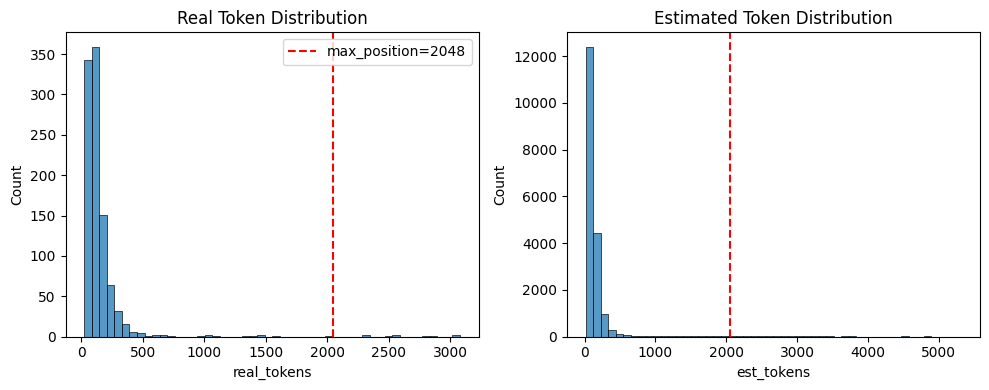

In [5]:
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

# 设置一个填充token（Qwen默认没有pad_token）
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 随机抽样1000条看看真实token长度
sample_df = df.sample(1000, random_state=42).copy()

def count_tokens(row):
    # 合并instruction + input + output（训练时实际会分开处理，这里先看总量）
    text = f"Instruction: {row['instruction']}\n"
    if row['input'] and len(row['input']) > 0:
        text += f"Input: {row['input']}\n"
    text += f"Output: {row['output']}"
    
    tokens = tokenizer.encode(text)
    return len(tokens)

sample_df['real_tokens'] = sample_df.apply(count_tokens, axis=1)

# 统计
print(sample_df['real_tokens'].describe().round(1))
print(f"超过2048 token: {(sample_df['real_tokens']>2048).sum()} ({(sample_df['real_tokens']>2048).mean()*100:.1f}%)")

# 画个分布图看看
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
sns.histplot(sample_df['real_tokens'], bins=50)
plt.axvline(2048, color='r', linestyle='--', label='max_position=2048')
plt.title('Real Token Distribution')
plt.legend()

plt.subplot(1,2,2)
sns.histplot(df['est_tokens'], bins=50)
plt.axvline(2048, color='r', linestyle='--')
plt.title('Estimated Token Distribution')
plt.tight_layout()
plt.show()

In [6]:
#QLoRA config

bnb_config_simple = BitsAndBytesConfig(
    load_in_4bit=True,
)
#Loading model
model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    quantization_config=bnb_config_simple,
    device_map="auto",
    trust_remote_code=True,
    use_cache=False
)

# 3. 加载tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct", 
    trust_remote_code=True,
    padding_side="right"                 # Qwen推荐right padding
)

# 设置pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


# 4. 准备k-bit训练（重要！处理量化后的梯度）
model = prepare_model_for_kbit_training(model)

# 5. LoRA配置（在8G显存上可以稍微大一点）
lora_config = LoraConfig(
    r=8,                                # 可以从8开始试，16也可
    lora_alpha=32,                       
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Qwen的注意力层
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

# 6. 看看可训练参数（确认QLoRA生效）
model.print_trainable_parameters()

Loading weights: 100%|██████████| 338/338 [00:08<00:00, 39.25it/s, Materializing param=model.norm.weight]                               


trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


In [7]:
# 加载tokenizer（用小的先测试，或者直接用7B的）
tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen2.5-7B-Instruct",
    trust_remote_code=True
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 定义过滤函数
def filter_by_token_length(df, max_length=2048, sample_size=None):
    """
    根据真实token长度过滤数据集
    sample_size: 如果是None，处理全部；如果设置数字，随机抽样测试
    """
    
    if sample_size:
        # 抽样测试模式
        test_df = df.sample(min(sample_size, len(df)), random_state=42)
        token_counts = []
        
        for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
            # 构造prompt（和训练时一致）
            text = f"Instruction: {row['instruction']}\n"
            if row['input'] and pd.notna(row['input']) and str(row['input']).strip():
                text += f"Input: {row['input']}\n"
            text += f"Output: {row['output']}"
            
            tokens = tokenizer.encode(text)
            token_counts.append(len(tokens))
        
        # 分析结果
        test_df['real_tokens'] = token_counts
        print("\n=== Token长度抽样分析 ===")
        print(test_df['real_tokens'].describe().round(1))
        
        # 估算过滤阈值
        p95 = np.percentile(token_counts, 95)
        p99 = np.percentile(token_counts, 99)
        print(f"\n95%分位数: {p95:.0f}")
        print(f"99%分位数: {p99:.0f}")
        print(f"超过2048: {(test_df['real_tokens']>2048).sum()} ({(test_df['real_tokens']>2048).mean()*100:.1f}%)")
        
        # 返回分析结果和推荐阈值
        return test_df, min(int(p99), max_length)
    
    else:
        # 批量处理模式（用你已有的est_tokens做粗略过滤）
        # 保守一点，留20%的余量（因为实际token可能比估算多）
        safe_threshold = int(max_length * 0.8)
        
        filtered_df = df[df['est_tokens'] <= safe_threshold].copy()
        dropped = len(df) - len(filtered_df)
        
        print(f"\n=== 批量过滤 ===")
        print(f"原始数据: {len(df)}")
        print(f"过滤后: {len(filtered_df)} (去掉 {dropped} 条, {dropped/len(df)*100:.1f}%)")
        print(f"阈值设置: est_tokens <= {safe_threshold} (预留20%给真实token)")
        
        return filtered_df

# 先用抽样测试看看真实分布
test_sample, recommended_threshold = filter_by_token_length(df, sample_size=1000)

# 然后根据测试结果决定阈值
# 如果测试显示大部分在1500以内，可以大胆用2048
# 如果测试显示接近2000的很多，就要保守一点
final_df = filter_by_token_length(df, max_length=2048, sample_size=None)

100%|██████████| 1000/1000 [00:00<00:00, 3768.57it/s]



=== Token长度抽样分析 ===
count    1000.0
mean      163.9
std       283.6
min        24.0
25%        76.0
50%       106.0
75%       160.0
max      3081.0
Name: real_tokens, dtype: float64

95%分位数: 333
99%分位数: 1600
超过2048: 9 (0.9%)

=== 批量过滤 ===
原始数据: 18612
过滤后: 18454 (去掉 158 条, 0.8%)
阈值设置: est_tokens <= 1638 (预留20%给真实token)


格式化数据: 100%|██████████| 18454/18454 [00:07<00:00, 2455.48it/s]



=== 最终数据集token分布 ===
count    18454.0
mean       161.5
std        116.9
min         43.0
25%        100.0
50%        132.0
75%        182.0
max       1024.0
Name: token_length, dtype: float64


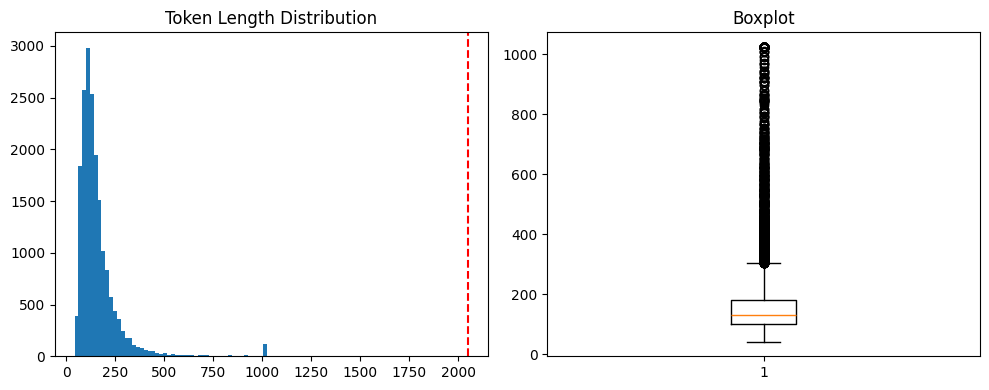

In [ ]:
def prepare_for_qwen_training(df, tokenizer, max_length=2048):
    """将清洗后的DataFrame转为训练格式"""
    
    formatted_data = []
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="格式化数据"):
        # 构建消息
        messages = []
        
        # user消息：instruction + input
        user_content = row['instruction']
        if row['input'] and pd.notna(row['input']) and str(row['input']).strip():
            user_content += f"\n\n{row['input']}"
        
        messages.append({"role": "user", "content": user_content})
        messages.append({"role": "assistant", "content": row['output']})
        
        # 应用chat template
        formatted_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
        
        # tokenization（用于训练）
        tokenized = tokenizer(
            formatted_text,
            truncation=True,
            max_length=max_length,
            padding=False,  # 先不padding，collator会处理
            return_tensors=None
        )
        
        formatted_data.append({
            "text": formatted_text,
            "input_ids": tokenized["input_ids"],
            "attention_mask": tokenized["attention_mask"],
            # 保留原始信息方便调试
            "instruction": row['instruction'],
            "input": row['input'] if pd.notna(row['input']) else "",
            "output": row['output'],
            "token_length": len(tokenized["input_ids"])
        })
    
    return pd.DataFrame(formatted_data)

# 执行转换
qwen_df = prepare_for_qwen_training(final_df, tokenizer, max_length=1024)

# 查看token长度分布
print("\n=== 最终数据集token分布 ===")
print(qwen_df['token_length'].describe().round(1))

import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(qwen_df['token_length'], bins=50)
plt.axvline(2048, color='r', linestyle='--')
plt.title('Token Length Distribution')

plt.subplot(1,2,2)
plt.boxplot(qwen_df['token_length'])
plt.title('Boxplot')
plt.tight_layout()
plt.show()

In [ ]:
# 转换为HuggingFace Dataset
hf_dataset = Dataset.from_pandas(qwen_df[['input_ids', 'attention_mask', 'text']])

# 添加labels
hf_dataset = hf_dataset.map(lambda x: {"labels": x["input_ids"]})

# 分割训练集和验证集
split_dataset = hf_dataset.train_test_split(test_size=0.05, seed=42)
train_dataset = split_dataset['train']
eval_dataset = split_dataset['test']

print(f"\n训练集: {len(train_dataset)} 条")
print(f"验证集: {len(eval_dataset)} 条")

import json

with open('train_data.jsonl', 'w') as f:
    for item in train_dataset:
        f.write(json.dumps({"text": item['text']}) + '\n')

with open('eval_data.jsonl', 'w') as f:
    for item in eval_dataset:
        f.write(json.dumps({"text": item['text']}) + '\n')

print("数据已保存为 train_data.jsonl 和 eval_data.jsonl")

# 训练时去掉text列
train_dataset = train_dataset.remove_columns(['text'])
eval_dataset = eval_dataset.remove_columns(['text'])

Map: 100%|██████████| 18454/18454 [00:01<00:00, 12737.58 examples/s]



训练集: 17531 条
验证集: 923 条
数据已保存为 train_data.jsonl 和 eval_data.jsonl


In [ ]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  
)

training_args = TrainingArguments(
    output_dir="./qwen-code-results",
    run_name="qwen-code-lora",
    
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    
    learning_rate=2e-4,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    eval_strategy="steps",
    eval_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",
    
    fp16=True,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    ddp_find_unused_parameters=False,
    
    remove_unused_columns=True,  # 改成True，自动过滤掉多余列
    dataloader_num_workers=0,    # 改成0，Windows/资源紧张时更稳定
)


# 3. 创建Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
)


print("\n开始训练...")
trainer.train()

print("\n保存模型...")
model.save_pretrained("./qwen-code-lora-final")
tokenizer.save_pretrained("./qwen-code-lora-final")

print("训练完成！模型已保存到 ./qwen-code-lora-final")


开始训练...


Step,Training Loss,Validation Loss
500,0.623132,0.596030
1000,0.607393,0.584671
1500,0.597227,0.580205
2000,0.579913,0.578404



保存模型...
训练完成！模型已保存到 ./qwen-code-lora-final


In [ ]:
# 加载模型
tokenizer = AutoTokenizer.from_pretrained("./qwen-code-lora-final")
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.float16,
    device_map="auto"
)
model = PeftModel.from_pretrained(base_model, "./qwen-code-lora-final")
model.eval()

# 测试
def generate(instruction, input_text=""):
    messages = [{"role": "user", "content": instruction + ("\n\n" + input_text if input_text else "")}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,
            temperature=0.7,
            do_sample=True,
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return response

print(generate("Write a Python function to check if a number is prime"))

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:06<00:00, 49.01it/s, Materializing param=model.norm.weight]                               


def is_prime(n):
    # 1 and negative numbers are not prime
    if n <= 1:
        return False
    
    # Check divisibility of the number by all integers up to its square root
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            return False
    
    return True


In [ ]:
BASE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
LORA_PATH = "./qwen-code-lora-final"
tokenizer = AutoTokenizer.from_pretrained(LORA_PATH)

def run_generate(model, instruction, max_new_tokens=256):
    messages = [{"role": "user", "content": instruction}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=max_new_tokens,
                                 do_sample=False, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

test_cases = [
    "Write a Python function to reverse a linked list",
    "Write a Python function to implement binary search",
]

# ── Base Model ──
print("加载 Base Model...")
base_model = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=torch.float16, device_map={"": 0})
base_model.eval()
base_results = {case: run_generate(base_model, case) for case in test_cases}

del base_model
torch.cuda.empty_cache()
print("Base Model 完成，显存已释放")

# ── LoRA Model ──
print("加载 LoRA Model...")
base_for_lora = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=torch.float16, device_map={"": 0})
lora_model = PeftModel.from_pretrained(base_for_lora, LORA_PATH, device_map={"": 0})
lora_model.eval()

for case in test_cases:
    lora_out = run_generate(lora_model, case)
    print("\n" + "=" * 65)
    print(f"📝 {case}")
    print("─" * 28 + " BASE " + "─" * 28)
    print(base_results[case])
    print("─" * 28 + " LORA " + "─" * 28)
    print(lora_out)

NameError: name 'AutoTokenizer' is not defined